In [164]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [165]:
import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import os,sys
sys.path.append("/home/mnurisso/miller_npl/generalization_transformer_marc/src")
import networkx as nx
import matplotlib.pyplot as plt

# Import necessary modules and classes
from MillerDataGen import MillerDataGenerator, DataGeneratorConfig

from MillerTest import MillerTestConfig, create_model
from MillerTrainer import MillerTrainer, TrainerConfig


In [166]:
N_INPUTS = 30 # Number of inputs
FEATURE_DIM = 10 # Number of latent dimensions
SEQUENCE_LEN = 3 # Number of items in the sim. test (includes probbe)
SAVE = False
NUM_SAMPLES = 2000
BATCH_SIZE = 128 
INIT_SCALE = 2 # Initialization scale
N_EPOCHS = 500


Create metric matrix


In [167]:
# Circle
t = torch.linspace(0,1,N_INPUTS).unsqueeze(1)
xx = torch.cat((torch.cos(2*torch.pi*t),torch.sin(2*torch.pi*t)),1)
METRIC_MATRIX = torch.cdist(xx,xx)

In [151]:
# Compositional
features = 3
dimensions = 3
F_comp = np.zeros((features**dimensions,dimensions*features),dtype="int")
for i in range(features**dimensions):
    istring = np.base_repr(i,features,dimensions)
    istring = istring[-dimensions:]
    for i_id,ichar in enumerate(istring):
        F_comp[i,i_id*features + int(ichar)] = 1
METRIC_MATRIX = torch.cdist(torch.tensor(F_comp).float(),torch.tensor(F_comp).float())**2

In [152]:
# Torus code
N = 7
neighbors = 2
A_grid = []
for i in range(N):
    for j in range(N):
        coords = np.zeros((N,N), dtype="int")
        for k1 in range(neighbors+1):
            for k2 in range(neighbors+1):
                coords[np.mod(i+k1,N),np.mod(j+k2,N)] = 1
        A_grid.append(coords.flatten())
A_grid = np.concatenate(np.array([A_grid]),0)
METRIC_MATRIX = torch.cdist(torch.tensor(A_grid).float(),torch.tensor(A_grid).float())**2

In [153]:
# Grid code
N = 7
neighbors = 2
A_grid = []
for i in range(N):
    for j in range(N):
        coords = np.zeros((N,N), dtype="int")
        for k1 in range(-neighbors+1,neighbors):
            for k2 in range(-neighbors+1, neighbors):
                coords[np.clip(i+k1,0,N-1),np.clip(j+k2,0,N-1)] = 1
        A_grid.append(coords.flatten())
A_grid = np.concatenate(np.array([A_grid]),0)
METRIC_MATRIX = torch.cdist(torch.tensor(A_grid).float(),torch.tensor(A_grid).float())**2

___

In [154]:
genconf = DataGeneratorConfig()
genconf.num_inputs = N_INPUTS
genconf.batch_size = BATCH_SIZE
genconf.num_samples = NUM_SAMPLES
genconf.sequence_len = SEQUENCE_LEN
genconf.metric_matrix = METRIC_MATRIX

gen = MillerDataGenerator(config = genconf)

model_config = MillerTestConfig(
            feature_dim=FEATURE_DIM,
            input_dim=genconf.num_inputs,
            sequence_len=genconf.sequence_len,
            init_scale = INIT_SCALE
        )

tconf = TrainerConfig()
tconf.losses = ["reconstruction","similarity"]
tconf.num_inputs = genconf.num_inputs
tconf.batch_size = BATCH_SIZE
tconf.num_epochs: int = N_EPOCHS
tconf.learning_rate: float = 7*1e-3
tconf.weight_decay: float = 0
tconf.patience = 700
tconf.min_lr = 0
tconf.lambda_rec = 0
tconf.lambda_sim = .1

model = create_model(model_config)
torch.nn.init.uniform_(model.embed.weight, a = 0*model_config.init_scale,b = model_config.init_scale)

trainer = MillerTrainer(model, gen, tconf)

In [155]:
history,embs = trainer.train(shutupfor = 100,compute_embeddings=True)


Epoch 0:
  Train - Sim Loss: 0.0693, Reconstruction Loss: 0.0000
  Val - G Score: 0.5109, I Score: 0.5664
Epoch 100:
  Train - Sim Loss: 0.0689, Reconstruction Loss: 0.0000
  Val - G Score: 0.7693, I Score: 0.8494
Epoch 200:
  Train - Sim Loss: 0.0691, Reconstruction Loss: 0.0000
  Val - G Score: 0.7614, I Score: 0.8791


KeyboardInterrupt: 

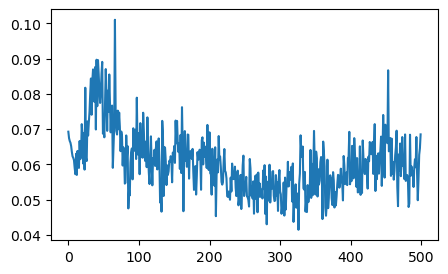

In [ ]:
f=plt.figure(figsize = (5,3))
plt.plot(history["similarity_losses"])

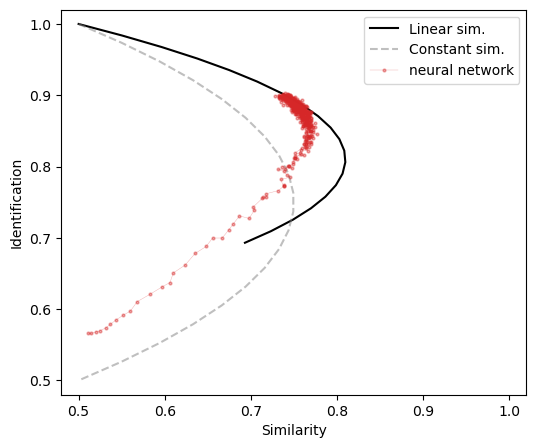

In [156]:
tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (6,5))

plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")
plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")



plt.plot(history['similarity_scores'],
        history['identification_scores'], 
        '-o', markersize = 2, linewidth = 0.3, alpha = .4, 
        color = "tab:red", label = "neural network")

#plt.scatter([histories[0]['similarity_scores'][0]],[histories[0]['identification_scores'][0]],color = "k", s = 100, zorder = 30, marker = "x")

plt.xlim([0.48,1.02])
plt.ylim([0.48,1.02])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend()

In [162]:
id_max_sim = 100#np.argmax(history['similarity_scores'])
S = np.maximum(0,embs[id_max_sim]@embs[id_max_sim].T)
S = S - np.diag(np.diag(S))
S = S
G = nx.Graph(S)

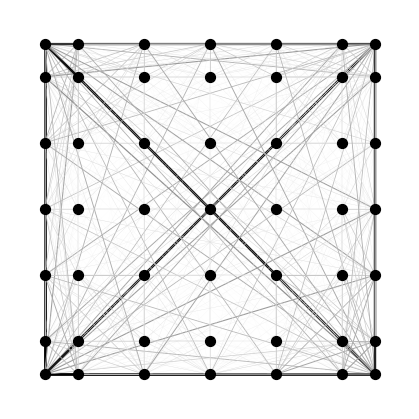

In [163]:
pos = [tuple(np.median(np.argwhere(A_grid[i,:].reshape(7,7)),0)) for i in range(N_INPUTS)]
maxx = np.max(S)
minn = np.min(S[S>0])
lws = np.array([1-(S[e[0],e[1]] - minn)/(maxx-minn) for e in G.edges])

f = plt.figure(figsize = (4,4))
nx.draw(G, pos = pos, edge_color = np.tile(lws,(3,1)).T, node_size = 50, node_color = "k", width = 2*(1-lws))

[]

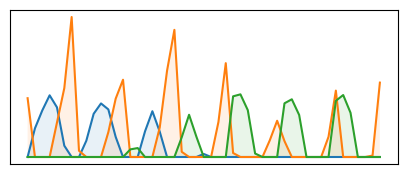

In [ ]:
xx = np.linspace(0,1,N_INPUTS)
ids = [10,20,29]
f = plt.figure(figsize = (5,2))
S = np.maximum(0,embs[-1]@embs[-1].T)
ax = plt.subplot(1,1,1)
for i in ids:
    ax.plot(xx,S[i,:])
    ax.fill_between(xx,0,S[i,:], alpha = 0.1)
ax.set_xticks([])
ax.set_yticks([])